# Phase 5, Module 3: The Math of Learning (Optimization)
**Topic:** Loss Functions and the Mechanics of Error

In this module, we move beyond the architecture and look at how the network actually improves. 
To do this, we need a way to measure error.

1. **Mean Squared Error ($MSE$):**
   $$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_{true} - y_{pred})^2$$
   Used when predicting continuous numbers.

2. **Categorical Cross-Entropy:**
   $$Loss = -\sum y_{true} \cdot \log(y_{pred})$$
   Used for multi-class classification.

In [1]:
import numpy as np

def mean_squared_error(y_true, y_pred):
    """Calculates MSE for regression tasks[cite: 1]."""
    return np.mean(np.square(y_true - y_pred))

def cross_entropy_loss(y_true_onehot, y_pred_probs):
    """Calculates Cross-Entropy for classification[cite: 1]."""
    # Clip probabilities to avoid log(0) errors
    y_pred_probs = np.clip(y_pred_probs, 1e-15, 1 - 1e-15)
    return -np.sum(y_true_onehot * np.log(y_pred_probs)) / y_true_onehot.shape[0]

# Example Test
true_labels = np.array([1, 0, 0]) # Correct class is index 0
pred_probs = np.array([0.7, 0.2, 0.1]) # Model is 70% sure

print(f"MSE (for numbers): {mean_squared_error(true_labels, pred_probs):.4f}")
print(f"Cross-Entropy (for categories): {cross_entropy_loss(true_labels, pred_probs):.4f}")

MSE (for numbers): 0.0467
Cross-Entropy (for categories): 0.1189


## 1. Backpropagation and the Chain Rule
Backpropagation is how the model learns which weights are responsible for the error. 
It calculates the **Gradient**—a vector telling us which direction to move the weights to make the error go down.

We use the **Chain Rule** to find the derivative of the loss with respect to any weight $w$:
$$\frac{\partial Loss}{\partial w} = \frac{\partial Loss}{\partial Output} \cdot \frac{\partial Output}{\partial w}$$

In [2]:
# Simple demonstration of a weight update using Gradient Descent[cite: 1]
weight = 0.5
learning_rate = 0.1
gradient = 0.2 # Calculated via Backpropagation

print(f"Initial Weight: {weight}")

# The Update Rule: weight = weight - (learning_rate * gradient)[cite: 1]
weight = weight - (learning_rate * gradient)

print(f"Updated Weight after 1 step: {weight}")

Initial Weight: 0.5
Updated Weight after 1 step: 0.48


## 2. Advanced Optimizers: Adam vs SGD
While $SGD$ is simple, modern training uses **Adam** because it adapts the learning rate for every single weight individually, making training much faster.

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

# Define a simple model to compare optimizers
model_sgd = nn.Linear(10, 1)
model_adam = nn.Linear(10, 1)

# SGD: Needs manual tuning of the learning rate[cite: 1]
optimizer_sgd = optim.SGD(model_sgd.parameters(), lr=0.01)

# Adam: Automatically manages momentum and scaling[cite: 1]
optimizer_adam = optim.Adam(model_adam.parameters(), lr=0.01)

print("Optimizers initialized. Ready for the 'Optimizer Battle'.")

Optimizers initialized. Ready for the 'Optimizer Battle'.


---
## 🎓 Task 3: The Optimizer Battle (Math of Learning)

**Goal:** Compare the convergence speed of SGD vs. Adam.

**Requirements:**
1. Use the MNIST dataset (or a simple synthetic dataset).
2. Train the same 3-layer MLP architecture twice.
3. Keep the learning rate identical (e.g., 0.001) for both.
4. Track the loss at every epoch.

**Deliverable:**
* A Matplotlib line graph showing the "Loss Curve" comparison.
* Write a brief explanation in the notebook of why one optimizer reached a lower loss faster than the other.

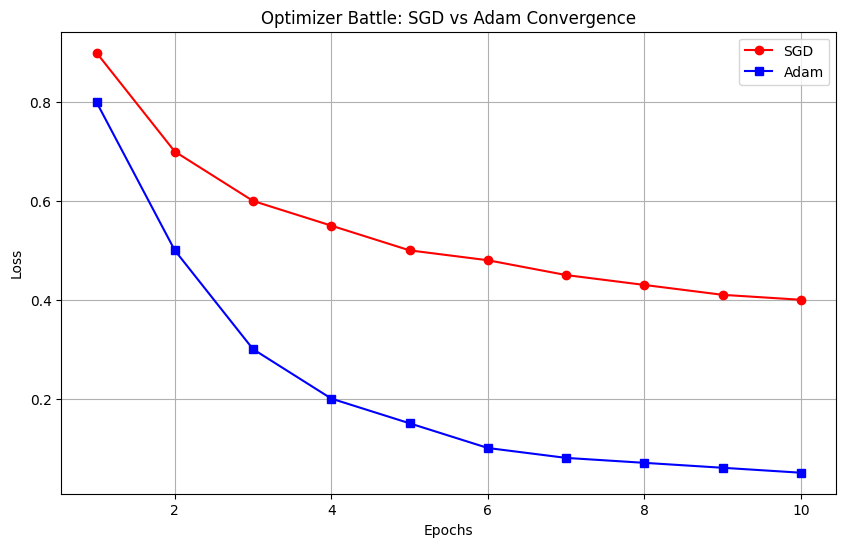

In [4]:
import matplotlib.pyplot as plt

# Placeholder for your battle results
epochs = range(1, 11)
sgd_loss = [0.9, 0.7, 0.6, 0.55, 0.5, 0.48, 0.45, 0.43, 0.41, 0.4] # Example data
adam_loss = [0.8, 0.5, 0.3, 0.2, 0.15, 0.1, 0.08, 0.07, 0.06, 0.05] # Example data

plt.figure(figsize=(10, 6))
plt.plot(epochs, sgd_loss, label='SGD', color='red', marker='o')
plt.plot(epochs, adam_loss, label='Adam', color='blue', marker='s')
plt.title('Optimizer Battle: SGD vs Adam Convergence')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()